# Toxic Comments Classification - BiLSTM

#### Author: SAFAA ENNACIRI - ENNS11538307                                 
#### Research Director: M. HAKIM LOUNIS

Dataset: JigsawToxic dataset is a dataset of comments from Wikipedia’s talk page edits. It is avaialble at Kaggle (https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge/data). 


The comments are divided in two classes: toxic and normal.

Algorithme used: BiLSTM

Preprocessing techniques used:
* Convert text to lowercase
* Remove emojis and emoticons
* Remove stop words
* Tokenization (accept all kind of tokens except spaces (returns, line breaks, tabs and multiple spaces))

# 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import pickle, time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, accuracy_score, recall_score, f1_score, precision_score
from skmultilearn.problem_transform import BinaryRelevance
from sklearn.model_selection import GridSearchCV,KFold
from sklearn.preprocessing import StandardScaler
from keras.wrappers.scikit_learn import KerasClassifier
from keras.layers import Dense, Input, Dropout
from keras import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.preprocessing import text
import re
from nltk.corpus import stopwords
from datetime_extractor import DateTimeExtractor

from tensorflow.keras.layers import Dense, Embedding,GlobalMaxPooling1D, GlobalMaxPool1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Bidirectional, LSTM
from tensorflow.keras.layers import Embedding
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.utils import to_categorical

import seaborn as sns
import pickle
import openpyxl 
from openpyxl import Workbook
from openpyxl.styles import Alignment
from openpyxl.styles.borders import Border, Side

# 2. Data Preparation 

In [2]:
# Load training data
df = pd.read_csv('../../Data/train_set4.csv')
df.head()

,id,text,tox,tokenized
0,30351,2few recognize that refugee crisis & associate...,0,"['2few', 'recognize', 'that', 'refugee', 'cris..."
1,31565,@RandomRandomero @shoe0nhead Also shut up abou...,1,"['@', 'RandomRandomero', '@', 'shoe0nhead', 'A..."
2,764,WATCH: Democratic Senator Doesn't Understand T...,1,"['WATCH', ':', 'Democratic', 'Senator', 'Does'..."
3,2106,IS-puppets tried to roll me over three times! ...,1,"['IS-puppets', 'tried', 'to', 'roll', 'me', 'o..."
4,5979,WHO.. ARE. YOOUU? This is not mario kart. You ...,1,"['WHO', '..', 'ARE', '.', 'YOOUU', '?', 'This'..."


In [3]:
# Load testing data
test = pd.read_csv('../../Data/test_set4.csv')
test.head()

,id,text,tox,tokenized
0,3816,#BuildThatWall #Meritbased get the ILLEGAL sit...,1,"['#', 'BuildThatWall', '#', 'Meritbased', 'get..."
1,2737,Angels Don't Die. I think it's better that two...,0,"['Angels', 'Do', ""n't"", 'Die', '.', 'I', 'thin..."
2,5598,When your girls actin a fool so you let your s...,1,"['When', 'your', 'girls', 'actin', 'a', 'fool'..."
3,19183,@PYS_FlyATL You pussy.,0,"['@', 'PYS_FlyATL', 'You', 'pussy', '.']"
4,1699,Tomorrow night our guest speaker is Madeleine ...,0,"['Tomorrow', 'night', 'our', 'guest', 'speaker..."


# 3. Preprocessing

In [4]:
import pickle, re

# load file  
with open('../../Data/Emoji_Dict.p', 'rb') as fp:
    Emoji_Dict = pickle.load(fp)
Emoji_Dict = {v: k for k, v in Emoji_Dict.items()}

#remove empjis
def remove_emojis(text):
    for emoj in Emoji_Dict:
        text = re.sub(r'('+emoj+')', " ", text)
    return text

In [5]:
# load file
with open('../../Data/Emoticon_Dict.p', 'rb') as fl:
    Emoticon_Dict = pickle.load(fl)

# remove emoticons
def remove_emoticons(text):
    emoticon_pattern = re.compile(u'(' + u'|'.join(k for k in Emoticon_Dict) + u')')
    return emoticon_pattern.sub(r'', text)

In [6]:
stop_words = set(stopwords.words('english'))

In [7]:
print(stop_words)

{'needn', 'once', 'his', 'after', 'has', "aren't", 'mustn', 'do', 'too', 't', "shouldn't", 'each', 'my', 'mightn', 'this', 'because', 'me', 'to', 'below', 've', 'ourselves', 'than', 'does', 'through', 'into', 'you', 'have', 'where', 'couldn', "hadn't", 'your', 'from', 'he', 'when', 'some', 'don', 'its', 'again', 'm', 'other', 'yourselves', 'themselves', 'd', 'ma', 'weren', "you'd", 'them', 'only', 'further', "that'll", 'out', 'should', 're', 'won', 'just', 'i', 'down', 'about', 'off', 'above', 'her', 'those', 'who', 'for', 'shan', 'or', 'll', 'am', 'while', 'so', "couldn't", 'under', "you've", "wouldn't", 'shouldn', 'between', 'be', 'can', 'then', "don't", 'yourself', 'we', 'himself', 'most', "it's", 'which', "should've", "hasn't", 'up', "wasn't", 'was', 'she', "won't", 'such', 'nor', 'these', 'any', 'it', 'haven', 'having', "doesn't", 'what', 'being', 'y', "shan't", 'why', 'aren', "mightn't", 'had', 'until', 'that', "weren't", 'over', 'they', 'not', 'and', 'herself', 'by', 'before', '

In [8]:
def clean_text(comment): 

    comment = comment.lower() # Normalize to lowercase 
    comment = remove_emojis(comment) # remove emojis
    comment = remove_emoticons(comment) # remove emoticons
            
    word_tokens = comment.split(' ') #word_tokenize(comment)
    
    filtered_comment = []  
    # converts the words in word_tokens tand tchecks whether 
    #they are present in stop_words or not
    for w in word_tokens:
        if w not in stop_words:
            filtered_comment.append(w)

    comment = (" ").join(filtered_comment)
    
    return comment

In [9]:
# clean and normalize comments
df['text'] = df['text'].map(lambda word:clean_text(word))
test['text'] = test['text'].map(lambda word:clean_text(word))

In [10]:
x_train, x_val, y_train, y_val = train_test_split(df['text'], df['tox'], test_size=0.15, random_state=42)

In [11]:
#Check shape of train data
print(x_train.shape)
print(y_train.shape)

(8840,)
(8840,)


In [12]:
#Check shape of validation data
print(x_val.shape)
print(y_val.shape)

(1560,)
(1560,)


In [13]:
x_test = test['text']
y_test = test['tox']

#Check shape of data
print(x_test.shape)
print(y_test.shape)

(2600,)
(2600,)


### Vectorize texts

In [14]:
# Create vocabulary with training texts.
tokenizer = text.Tokenizer(num_words=20000, filters='\r\t\n', lower=False)  # Limit on the number of features. We use the top 20K features.
tokenizer.fit_on_texts(list(x_train)+ list(x_val) + list(x_test))

# Vectorize training texts.
tokenized_train = tokenizer.texts_to_sequences(x_train)
tokenized_val = tokenizer.texts_to_sequences(x_val)
tokenized_test = tokenizer.texts_to_sequences(x_test)

In [15]:
# Limit on the length of text sequences. Sequences longer than this
# will be truncated.
MAX_SEQUENCE_LENGTH = 100


# Get max sequence length.
max_length = len(max(x_train, key=len))
if max_length > MAX_SEQUENCE_LENGTH:
       max_length = MAX_SEQUENCE_LENGTH

In [16]:
# Fix sequence length to max value. Sequences shorter than the length are
# padded in the end and sequences longer are truncated
# at the end.
X_train = pad_sequences(tokenized_train, maxlen=max_length, padding= 'post')
X_val = pad_sequences(tokenized_val, maxlen=max_length, padding= 'post')
X_test = pad_sequences(tokenized_test, maxlen=max_length, padding= 'post')

In [17]:
# Get length of corpus's word index
vocab_size=(len(tokenizer.word_index)+1)
print(vocab_size)

45754


###  converts a class vector (integers) to binary class matrix.

In [18]:
# converts a class vector (integers) to binary class matrix.
Y_train=to_categorical(y_train)
#Check shape of data
Y_train.shape

(8840, 2)

In [19]:
# converts a class vector (integers) to binary class matrix.
Y_val=to_categorical(y_val)
#Check shape of data
Y_val.shape

(1560, 2)

In [20]:
# converts a class vector (integers) to binary class matrix.
Y_test=to_categorical(y_test)
#Check shape of data
Y_test.shape

(2600, 2)

In [21]:
Y_val[:2]

array([[1., 0.],
       [0., 1.]], dtype=float32)

In [22]:
Y_test[:2]

array([[0., 1.],
       [1., 0.]], dtype=float32)

In [23]:
Y_train[:2]

array([[1., 0.],
       [1., 0.]], dtype=float32)

# 3. Create model

In [24]:
EMBEDDING_DIM=400

def model_to_optimize(optimizer='RMSprop'): #learning_rate = 0.001 default value
         
    model = Sequential()
    
    seq = Input(shape=(max_length,))
    input_seq = Embedding(
        input_dim = vocab_size, input_length = max_length,output_dim = EMBEDDING_DIM)(seq)
    
    layer = Bidirectional(LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.3))(input_seq)
    layer = GlobalMaxPool1D()(layer)
    output = Dense(2, activation='softmax')(layer) 
        
    model = Model(inputs=seq, outputs=output)
        
    model.compile(loss='binary_crossentropy',optimizer=optimizer, metrics=['accuracy'])
    return model

In [25]:
from keras import backend, Model

model_used = model_to_optimize()
# summarize model
model_used.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 100)]             0         
_________________________________________________________________
embedding (Embedding)        (None, 100, 400)          18301600  
_________________________________________________________________
bidirectional (Bidirectional (None, 100, 128)          238080    
_________________________________________________________________
global_max_pooling1d (Global (None, 128)               0         
_________________________________________________________________
dense (Dense)                (None, 2)                 258       
Total params: 18,539,938
Trainable params: 18,539,938
Non-trainable params: 0
_________________________________________________________________


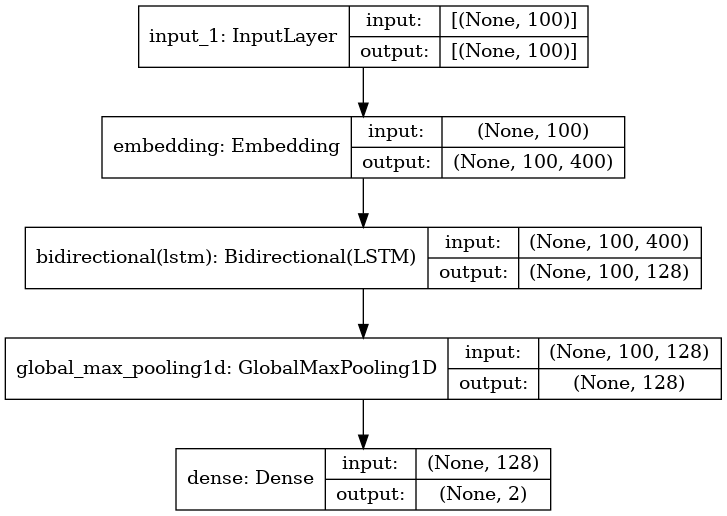

In [26]:
# plot model
plot_model(model_used, show_shapes=True)

In [27]:
## Define your callbacks
Modle_Checkpoint = ModelCheckpoint(
    'modles/bilstm_approach#17.h5',
    monitor='val_loss',
    save_best_only='True',
    mode='min',
    verbose=1
)

Early_Stopping = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,
    verbose=1,
    restore_best_weights='True',
    min_delta=0
)

In [28]:
callbacks = [Early_Stopping, Modle_Checkpoint, ]

### Train classifier

In [29]:
history = model_used.fit(X_train,Y_train, epochs=100,
                            callbacks=callbacks,
                            batch_size=128, #litterature review
                            validation_data=(X_val, Y_val),
                            verbose=True)

Epoch 1/100
70/70 [==============================] - 94s 1s/step - loss: 0.6239 - accuracy: 0.6445 - val_loss: 0.5371 - val_accuracy: 0.7359

Epoch 00001: val_loss improved from inf to 0.53709, saving model to modles/bilstm_approach#17.h5
Epoch 2/100
70/70 [==============================] - 92s 1s/step - loss: 0.4429 - accuracy: 0.7997 - val_loss: 0.5390 - val_accuracy: 0.7436

Epoch 00002: val_loss did not improve from 0.53709
Epoch 3/100
70/70 [==============================] - 91s 1s/step - loss: 0.3283 - accuracy: 0.8613 - val_loss: 0.6361 - val_accuracy: 0.7224

Epoch 00003: val_loss did not improve from 0.53709
Epoch 4/100
70/70 [==============================] - 90s 1s/step - loss: 0.2502 - accuracy: 0.8992 - val_loss: 0.6937 - val_accuracy: 0.7192

Epoch 00004: val_loss did not improve from 0.53709
Epoch 5/100
70/70 [==============================] - 88s 1s/step - loss: 0.1978 - accuracy: 0.9219 - val_loss: 0.8042 - val_accuracy: 0.7064

Epoch 00005: val_loss did not improve fr

### Evaluate metrics

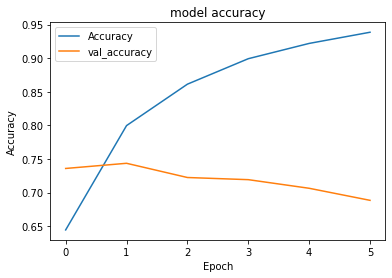

In [30]:
import matplotlib.pyplot as plt
hist = history.history
plt.plot(hist["accuracy"])
plt.plot(hist['val_accuracy'])
plt.title("model accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Accuracy","val_accuracy"])
plt.show()

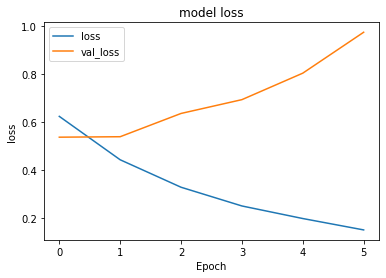

In [31]:
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("Epoch")
plt.legend(["loss","val_loss"])
plt.show()

In [32]:
from keras.models import load_model
saved_model = load_model("modles/bilstm_approach#17.h5")

result = saved_model.evaluate(X_train,Y_train,
                               batch_size=128, #litterature review
                            verbose=True)


70/70 [==============================] - 13s 183ms/step - loss: 0.4639 - accuracy: 0.7967


In [33]:
print("train loss: %0.3f" % result[0])
print("train acc: %0.3f" % result[1])

train loss: 0.464
train acc: 0.797


In [34]:
result_val = saved_model.evaluate(X_val,Y_val,
                               batch_size=128, #litterature review
                            verbose=True)

13/13 [==============================] - 2s 177ms/step - loss: 0.5371 - accuracy: 0.7359


In [35]:
print("validation loss: %0.3f" % result_val[0])
print("validation acc: %0.3f" % result_val[1])

validation loss: 0.537
validation acc: 0.736


In [36]:
train_accuracy = "%.4f" % (result[1])
train_Loss = r"%.4f" % (result[0])
val_accuracy = "%.4f" % (result_val[1])
val_loss = "%.4f" % (result_val[0])

# 4. Predictions

### Test set

In [37]:
y_pred=saved_model.predict(X_test, batch_size=128, verbose=True)

21/21 [==============================] - 4s 190ms/step


In [38]:
print(y_pred)

[[0.03399922 0.9660008 ]
 [0.9666834  0.03331653]
 [0.15962754 0.84037244]
 ...
 [0.8675934  0.13240659]
 [0.89828354 0.10171647]
 [0.786365   0.21363504]]


In [39]:
print(Y_train)

[[1. 0.]
 [1. 0.]
 [1. 0.]
 ...
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [40]:
print(Y_test)

[[0. 1.]
 [1. 0.]
 [0. 1.]
 ...
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [41]:
print("\n Accuracy: %0.2f" % accuracy_score(np.argmax(Y_test, axis=1), np.argmax(y_pred, axis=1)))
print("\n Confusion matrix\n")
print(classification_report(np.argmax(Y_test, axis=1), np.argmax(y_pred, axis=1)))


 Accuracy: 0.72

 Confusion matrix

              precision    recall  f1-score   support

           0       0.71      0.85      0.78      1465
           1       0.74      0.56      0.64      1135

    accuracy                           0.72      2600
   macro avg       0.73      0.70      0.71      2600
weighted avg       0.73      0.72      0.71      2600



In [42]:
y_pred=np.argmax(y_pred, axis=1)
Y_test=np.argmax(Y_test, axis=1)
cm = confusion_matrix(Y_test, y_pred)
print(cm)

[[1248  217]
 [ 505  630]]


In [43]:
# Model Evaluation metrics for test data
test_accuracy = "%.4f" % (accuracy_score(Y_test, y_pred))
test_recall  = "%.4f" % (recall_score(Y_test, y_pred))
test_F1_score  = "%.4f" % (f1_score(Y_test, y_pred))
test_precision  = "%.4f" % (precision_score(Y_test, y_pred))

# Print scores for evaluation metrics
print('Results for test data')
print ('-----------------------')
print('Accuracy score : ', test_accuracy)
print('recall : ', test_recall)
print('F1_score : ' , test_F1_score)
print('precision : ' , test_precision)

Results for test data
-----------------------
Accuracy score :  0.7223
recall :  0.5551
F1_score :  0.6357
precision :  0.7438


# 5. Save results to Excel file

In [44]:
# define tarjet
newFile = "../results_BiLSTM_set4.xlsx"

# open excel file
workbook = openpyxl.load_workbook(filename = newFile)        
worksheet = workbook.active
    
# scores for evaluation metrics
data = {1:'Approach #17', 2:train_accuracy, 3:train_Loss, 4:val_accuracy, 5:val_loss, 
                  6:test_accuracy, 7:test_recall, 8:test_F1_score, 9:test_precision}

# row's index for approach#1
index = 19

# delete row of approach#1
worksheet.delete_rows(index, 1)

# insert data in excel sheet
worksheet.insert_rows(index)
for col, value in data.items():
    worksheet.cell(row=index, column=col, value=value)
    
# define style border
thin_border = Border(left=Side(style='thin'), 
                     right=Side(style='thin'), 
                     top=Side(style='thin'), 
                     bottom=Side(style='thin'))
cell_alignment = Alignment(horizontal='center')

# apply style border
for row in worksheet:
    for cell in row:
        cell.border = thin_border
        cell.alignment = cell_alignment
    
# save file
workbook.save(newFile)